<a href="https://colab.research.google.com/github/switlanakostyuk-ctrl/Apollo/blob/main/HW_16_2_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BA%D1%80%D0%B5%D0%B4%D0%B8%D1%82%D0%BD%D0%BE%D0%B3%D0%BE_%D1%80%D0%B8%D0%B7%D0%B8%D0%BA%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [29]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [30]:
df = pd.read_csv('credit_risk_dataset.csv')

print(f"Розмір датасету: {df.shape}")
print(f"Кількість клієнтів: {df.shape[0]:,}")
print(f"Кількість ознак: {df.shape[1]}")

Розмір датасету: (32581, 12)
Кількість клієнтів: 32,581
Кількість ознак: 12


In [31]:
# Перші 5 рядків даних
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [32]:
# Типи даних
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# Аналіз цільової змінної

In [33]:
target_dist = df['loan_status'].value_counts()
target_percent = df['loan_status'].value_counts(normalize=True) * 100

target_percent

,proportion
loan_status,
0,78.183604
1,21.816396


# Висновок

Це задача незбалансованої класифікації:

- один клас (0) значно переважає (~78%)

- інший клас (1) представлений значно менше (~22%)

Це означає, що модель може бути зміщеною в сторону класу 0, тому для оцінки якості необхідно використовувати не лише accuracy, а й precision, recall та F1-score.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [34]:
# Перевірка пропущених значень
missing = df.isnull().sum()
missing[missing > 0]

,0
person_emp_length,895
loan_int_rate,3116


In [35]:
# заповнення
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Аналіз числових змінних

In [36]:
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Спостерігається значна варіативність доходу (person_income), що може свідчити про наявність викидів.

Також видно, що значення loan_percent_income варіюється в широкому діапазоні, що може впливати на ризик дефолту.

# Викиди

In [37]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['person_income'] >= lower) & (df['person_income'] <= upper)]

Було виявлено викиди в змінній person_income за допомогою IQR.

Викиди були видалені, оскільки вони можуть спотворювати модель та негативно впливати на її якість.

In [38]:
fig = px.box(
    df,
    x='loan_status',
    y='person_income',
    title='Дохід vs Дефолт',
    color='loan_status'
)
fig.show()

Висновок:

Клієнти, які допустили дефолт, в середньому мають нижчий дохід порівняно з тими, хто повернув кредит.

Це логічно, оскільки нижчий дохід означає меншу платоспроможність і більший ризик невиконання кредитних зобов’язань.

Таким чином, змінна person_income є важливим фактором для прогнозування дефолту.

In [39]:
fig = px.box(
    df,
    x='loan_status',
    y='loan_int_rate',
    title='Ставка vs Дефолт',
    color='loan_status'
)
fig.show()

Висновок:

Клієнти з дефолтом мають вищі процентні ставки за кредитом.

Це може означати, що банки вже оцінюють таких клієнтів як більш ризикових і встановлюють вищі ставки.

Також висока ставка збільшує фінансове навантаження, що підвищує ймовірність дефолту.

Отже, loan_int_rate є одним з ключових предикторів ризику.

# Загальний висновок:

Аналіз показує, що фінансові характеристики клієнта (дохід та процентна ставка) мають суттєвий вплив на ймовірність дефолту.

Менший дохід та більша процентна ставка пов’язані з підвищеним ризиком невиплати кредиту.

Це підтверджує доцільність використання цих ознак у моделі машинного навчання. Незважаючи на наявність перекриття між класами, розподіли суттєво відрізняються, що свідчить про наявність сигналу для моделі.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



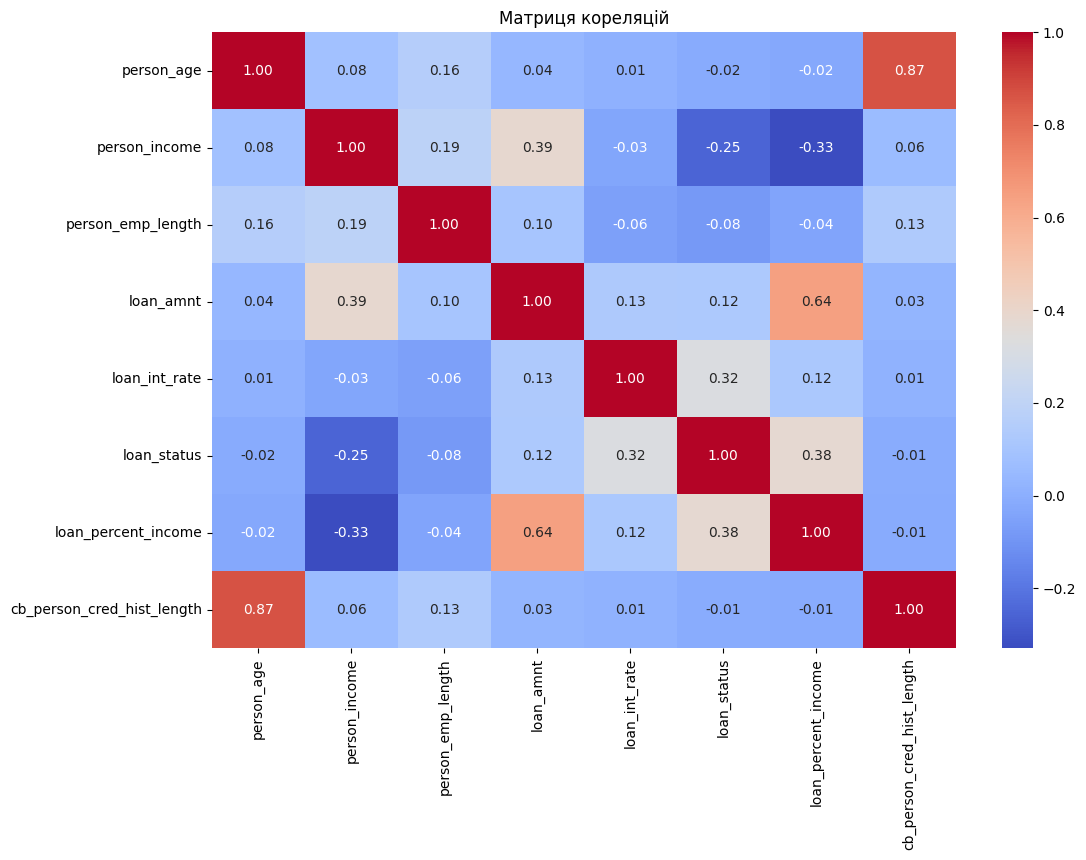

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Матриця кореляцій')
plt.show()

In [41]:
corr_table = (
    df_encoded.corr()['loan_status']
    .sort_values(ascending=False)
    .to_frame(name='Correlation with loan_status'))

corr_table

,Correlation with loan_status
loan_status,1.000000
loan_percent_income,0.379806
loan_int_rate,0.320203
loan_grade_D,0.319804
is_high_risk,0.240212
person_home_ownership_RENT,0.237524
cb_person_default_on_file_Y,0.179496
loan_grade_E,0.178959
loan_amnt,0.123433
loan_grade_F,0.100571


Найсильніший позитивний зв’язок з дефолтом має змінна loan_percent_income (0.38), що означає: чим більшу частку доходу становить кредит, тим вищий ризик неповернення.

     Також суттєвий позитивний зв’язок мають:


loan_int_rate (0.32) — високі процентні ставки пов’язані з більшим ризиком дефолту;

loan_grade_D та loan_grade_E — нижчий кредитний рейтинг підвищує ймовірність дефолту;

person_home_ownership_RENT — оренда житла асоціюється з вищим кредитним ризиком.

      Негативну кореляцію з дефолтом мають:

person_income (-0.25) — вищий дохід знижує ризик;

income_to_loan_ratio (-0.19) — краща здатність покривати кредит зменшує ймовірність дефолту;

person_home_ownership_OWN (-0.10) — власне житло свідчить про більшу фінансову стабільність.



Отримані результати підтверджують, що ключовими факторами кредитного ризику є фінансове навантаження, кредитний рейтинг та загальна фінансова стабільність позичальника.

In [42]:
grade_default = df.groupby(['loan_grade','loan_status']).size().unstack()
grade_pct = grade_default.div(grade_default.sum(axis=1), axis=0) * 100

fig = px.bar(
    grade_pct.T,
    title='Дефолт за кредитним рейтингом',
    barmode='group')

fig.show()

In [43]:
df['income_to_loan_ratio'] = df['person_income'] / df['loan_amnt']
df['is_high_risk'] = (df['loan_percent_income'] > 0.4).astype(int)

In [44]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Висновок:

чим гірший рейтинг → тим більше дефолтів.


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [45]:
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 24
Розмір вибірки: 31097


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Навчання моделі логічстичної прогресії

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

# Прогноз

In [49]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

In [50]:
import pandas as pd

# 1. Робимо прогнози (як у вас і було)
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1] # ймовірність того, що буде 1 (дефолт)

# 2. Створюємо зручну таблицю для перевірки результатів на тестовій вибірці
comparison_df = pd.DataFrame({
    'Реальний статус': y_test.values,
    'Прогноз моделі': y_test_pred,
    'Ймовірність дефолту (%)': (y_test_proba * 100).round(2)
})

# 3. Виводимо перші 10 записів, щоб подивитися на них
print("Порівняння реальних даних з прогнозом:")
print(comparison_df.head(10))

# 4. Додамо трохи статистики для наочності
correct_preds = (comparison_df['Реальний статус'] == comparison_df['Прогноз моделі']).sum()
total_preds = len(comparison_df)
print(f"\nТочність (Accuracy) на цих даних: {correct_preds/total_preds:.2%}")

Порівняння реальних даних з прогнозом:
   Реальний статус  Прогноз моделі  Ймовірність дефолту (%)
0                0               0                     3.01
1                0               0                     1.53
2                0               0                     3.70
3                0               0                     3.33
4                0               1                    85.39
5                0               0                     2.78
6                1               1                    53.33
7                1               0                    29.06
8                0               0                    16.49
9                1               0                    43.33

Точність (Accuracy) на цих даних: 86.74%



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


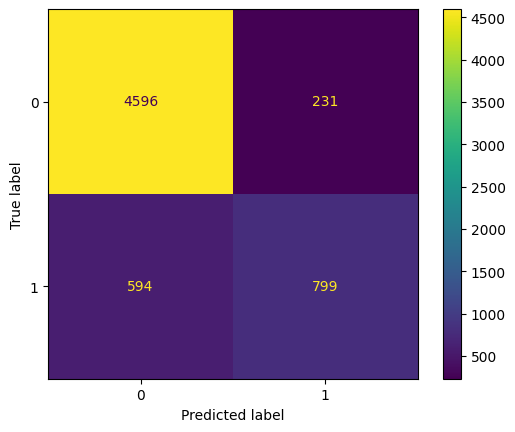

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# Висновок:

Модель демонструє достатньо хорошу якість класифікації.

Вона добре визначає надійних клієнтів (велика кількість True Negative), що свідчить про високу загальну точність.

Проте модель пропускає значну кількість дефолтних клієнтів (False Negative = 594), що є критичним недоліком для задачі кредитного ризику.

*Це означає, що модель не завжди ефективно виявляє ризикових позичальників.*



---



З точки зору бізнесу, найбільш небезпечною є помилка типу False Negative — коли дефолтний клієнт класифікується як надійний. У даному випадку таких помилок досить багато, що може призводити до значних фінансових втрат.

Натомість кількість False Positive (231) є відносно невеликою, що означає, що модель рідко відмовляє хорошим клієнтам. Отже, модель є прийнятною, але потребує оптимізації, зокрема зміни порогу класифікації для збільшення recall.

Це дозволить зменшити кількість пропущених дефолтів.


---


**Найбільш впливовими ознаками для моделі є:**

loan_percent_income — відношення кредиту до доходу (чим більше, тим вищий ризик дефолту)

loan_grade (особливо D та E) — гірший кредитний рейтинг підвищує ризик

person_home_ownership — оренда житла збільшує ризик, власне житло зменшує

person_income — вищий дохід знижує ймовірність дефолту

loan_amnt — більші кредити пов’язані з нижчим ризиком, що може пояснюватись відбором надійніших позичальників

Загалом модель спирається на ознаки, що відображають фінансове навантаження та стабільність клієнта, що відповідає реальній логіці оцінки кредитного ризику.

# Важливість ознак:

In [52]:
importance = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0],
    'abs_coef': np.abs(model.coef_[0])
}).sort_values('abs_coef', ascending=False)

importance.head(10)

,feature,coef,abs_coef
5,loan_percent_income,1.369683,1.369683
19,loan_grade_D,0.824974,0.824974
20,loan_grade_E,0.485478,0.485478
10,person_home_ownership_OWN,-0.459543,0.459543
11,person_home_ownership_RENT,0.411999,0.411999
16,loan_intent_VENTURE,-0.401465,0.401465
3,loan_amnt,-0.384603,0.384603
7,income_to_loan_ratio,0.333176,0.333176
12,loan_intent_EDUCATION,-0.325819,0.325819
1,person_income,-0.324399,0.324399


# Метрики:

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.867363344051447
Precision: 0.7757281553398059
Recall: 0.5735821966977745
F1: 0.6595130004127115


Модель демонструє високу загальну точність (Accuracy = 0.867), однак ця метрика є менш інформативною через незбалансованість класів.

Precision = 0.776 свідчить про те, що модель досить точно ідентифікує дефолтних клієнтів і рідко помиляється у вигляді хибних спрацювань.

Водночас Recall = 0.574 показує, що модель виявляє лише близько 57% реальних дефолтів, тобто значна частина ризикових клієнтів залишається непоміченою.

F1-score = 0.66 підтверджує, що модель має середній баланс між точністю та повнотою, але її ефективність обмежується низьким значенням Recall.

Отже, для задачі кредитного скорингу модель потребує оптимізації, зокрема зниження порогу класифікації для покращення виявлення дефолтів.

# ROC + AUC

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:,1])
auc = roc_auc_score(y_test, y_pred_proba[:,1])

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f"AUC={auc:.3f}"))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], line=dict(dash='dash')))
fig.show()

Це ROC-крива + AUC, вона говорить, що модель доволі хороша — навіть краще, ніж виглядало тільки по confusion matrix.

ROC-крива показує

По осі X (FPR) — частка помилкових спрацювань (False Positive Rate)

По осі Y (TPR) — recall (True Positive Rate)

Кожна точка — це інший поріг класифікації.  

AUC = 0.874 означає що у 87.4% випадків модель правильно поставить дефолтника вище (по ймовірності), ніж недефолтника.


Отже, модель має хороший потенціал, але потребує оптимізації порогу класифікації для покращення recall.

# Висновок

Якість моделі:
Модель логістичної регресії показала хорошу якість — значення AUC = 0.874 свідчить про високу здатність моделі відрізняти надійних позичальників від ризикових. Це означає, що модель добре ранжує клієнтів за рівнем кредитного ризику.

Точність та бізнес-ризики:
При стандартному порозі 0.5 модель пропускає значну частину дефолтів (Recall ≈ 0.57), тобто близько 43% ризикових клієнтів не ідентифікуються.
З точки зору бізнесу це може призводити до суттєвих фінансових втрат.

Зниження порогу класифікації до 0.3–0.4 дозволяє підвищити виявлення дефолтів (Recall), зменшити ризик втрат ціною незначного збільшення помилкових спрацювань (FP).

Таким чином, оптимальний поріг залежить від того, що для бізнесу дорожче — пропустити дефолт чи помилково відхилити клієнта.


Найбільш значущими ознаками, що підвищують ймовірність ризику, є:

loan_percent_income — чим більша частка доходу витрачається на кредит, тим вищий ризик (найсильніший фактор)

низький кредитний рейтинг (loan_grade D та E) — суттєво підвищує ймовірність дефолту
оренда житла (RENT) — пов’язана з вищим фінансовим ризиком

Фактори надійності:


власне житло (OWN) — свідчить про фінансову стабільність

вищий дохід (person_income) — підвищує здатність обслуговувати кредит




---



Модель демонструє логічні та інтерпретовані залежності і може бути ефективно використана для оцінки кредитного ризику.
Найважливішими факторами є фінансове навантаження на клієнта та його кредитна історія.

Для практичного застосування критично важливо правильно обрати поріг класифікації, оскільки це безпосередньо впливає на баланс між фінансовими втратами та кількістю помилкових рішень.


## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



# Поріг рішення:

In [55]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    preds = (y_pred_proba[:,1] >= t).astype(int)

    results.append({
        'threshold': t,
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)  })

metrics_df = pd.DataFrame(results)
metrics_df

,threshold,precision,recall,f1
0,0.10,0.391982,0.884422,0.543210
1,0.15,0.470494,0.847093,0.604973
2,0.20,0.533333,0.804020,0.641283
3,0.25,0.583151,0.765255,0.661906
4,0.30,0.636082,0.736540,0.682635
5,0.35,0.678720,0.700646,0.689509
6,0.40,0.711851,0.659727,0.684799
7,0.45,0.739914,0.618808,0.673964
8,0.50,0.775728,0.573582,0.659513
9,0.55,0.795479,0.530510,0.636520


In [56]:
import plotly.express as px

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах класифікації',
    labels={
        'value': 'Значення метрики',
        'threshold': 'Поріг'   }  )

fig.show()

Вибір оптимального порогу:

In [57]:
best_row = metrics_df.loc[metrics_df['f1'].idxmax()]
best_row

,5
threshold,0.350000
precision,0.678720
recall,0.700646
f1,0.689509


In [58]:
optimal_threshold = 0.35

y_pred_opt = (y_pred_proba[:,1] >= optimal_threshold).astype(int)

In [59]:
print(metrics_df.sort_values('f1', ascending=False).head())

   threshold  precision    recall        f1
5       0.35   0.678720  0.700646  0.689509
6       0.40   0.711851  0.659727  0.684799
4       0.30   0.636082  0.736540  0.682635
7       0.45   0.739914  0.618808  0.673964
3       0.25   0.583151  0.765255  0.661906


Аналіз метрик при різних порогах класифікації показав, що зі зменшенням порогу зростає recall (модель знаходить більше дефолтів), але зменшується precision (збільшується кількість помилкових тривог).

Максимальне значення F1-score (0.689) досягається при порозі ≈ 0.35, що забезпечує найкращий баланс між precision (0.68) та recall (0.70).

З бізнес-точки зору доцільно використовувати поріг 0.35, оскільки це дозволяє виявляти більшу кількість ризикових клієнтів і зменшити фінансові втрати від дефолтів, навіть за рахунок збільшення кількості помилкових спрацювань.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)}

results = []

for name, model in models.items():

    # Для Logistic Regression використовується scaled data
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-score': f1_score(y_test, preds)  })

results_df = pd.DataFrame(results)

results_df.sort_values('F1-score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.927814,0.950382,0.715004,0.816059
1,Decision Tree,0.887299,0.742637,0.760230,0.751330
0,Logistic Regression,0.867363,0.775728,0.573582,0.659513


In [62]:
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.867363,0.775728,0.573582,0.659513
1,Decision Tree,0.887299,0.742637,0.760230,0.751330
2,Random Forest,0.927814,0.950382,0.715004,0.816059


# Висновок


Найкращий результат показала модель Random Forest.

Вона досягла:
- найвищого Accuracy (0.928),
- найвищого Precision (0.95),
- та найкращого F1-score (0.816).

Це свідчить про те, що модель дуже добре відрізняє дефолтних клієнтів від надійних позичальників та рідко помиляється при прогнозуванні дефолту.

Decision Tree також показала хороші результати, особливо за Recall (0.76), тобто краще виявляла ризикових клієнтів, однак поступалася Random Forest за загальною стабільністю та точністю.

Logistic Regression показала найнижчі результати серед трьох моделей, проте залишається корисною завдяки простоті та інтерпретованості.

Отже, для задачі прогнозування кредитного ризику найбільш ефективною моделлю виявився Random Forest, оскільки він забезпечує найкращий баланс між точністю та повнотою класифікації.